# Dataset Analysis

### 1. Setup & Imports

In [25]:
# ## 1. Setup & Imports

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import cv2
from scipy.fft import fft2, fftshift
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')



In [26]:
# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Paths to your local datasets (UPDATE THESE)
DATA_DIR = Path("./data")   # Change to your actual data folder
TINY_TRAIN_DIR = DATA_DIR / "tiny_imagenet" / "train"
CELEBA_DIR = DATA_DIR / "celeba" / "img_align_celeba"

print(f"Tiny ImageNet path: {TINY_TRAIN_DIR}")
print(f"CelebA path: {CELEBA_DIR}")
print(f"Tiny exists: {TINY_TRAIN_DIR.exists()}")
print(f"CelebA exists: {CELEBA_DIR.exists()}")

Tiny ImageNet path: data\tiny_imagenet\train
CelebA path: data\celeba\img_align_celeba
Tiny exists: True
CelebA exists: True


### 2. Loading Images – load_images()

In [ ]:
# ## 2. Load images from local folders 

def load_images(folder, max_images=5000, target_size=(64,64)):
    """
    Load images from folder.
    For Tiny ImageNet: subfolders per class.
    For CelebA: flat folder of .jpg files.
    Returns numpy array of images.
    """
    images = []
    if folder.name == "train":  # Tiny ImageNet structure
        class_folders = [f for f in folder.iterdir() if f.is_dir()]
        for cf in class_folders:
            img_folder = cf / "images"
            if img_folder.exists():
                for img_path in list(img_folder.glob("*.JPEG"))[:max_images//len(class_folders)]:
                    img = cv2.imread(str(img_path))
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, target_size)
                        images.append(img)
                        if len(images) >= max_images:
                            break
            if len(images) >= max_images:
                break
    else:  # CelebA: flat folder
        for img_path in list(folder.glob("*.jpg"))[:max_images]:
            img = cv2.imread(str(img_path))
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                images.append(img)
            if len(images) >= max_images:
                break
    return np.array(images)

SAMPLE_SIZE = 5000  # Adjust based on your RAM
print("Loading Tiny ImageNet samples...")
tiny_imgs = load_images(TINY_TRAIN_DIR, max_images=SAMPLE_SIZE, target_size=(64,64))
print(f"Loaded {len(tiny_imgs)} Tiny images, shape: {tiny_imgs.shape}")

print("Loading CelebA samples...")
celeba_imgs = load_images(CELEBA_DIR, max_images=SAMPLE_SIZE, target_size=(64,64))
print(f"Loaded {len(celeba_imgs)} CelebA images, shape: {celeba_imgs.shape}")

Loading Tiny ImageNet samples...
Loaded 5000 Tiny images, shape: (5000, 64, 64, 3)
Loading CelebA samples...
Loaded 5000 CelebA images, shape: (5000, 64, 64, 3)


### 3. Basic Statistics 

In [30]:
# ## 3. Basic Statistics (mean, std, min, max, percentiles)

def basic_stats(images):
    stats = {}
    stats['mean'] = np.mean(images, axis=(0,1,2))
    stats['std'] = np.std(images, axis=(0,1,2))
    stats['min'] = np.min(images)
    stats['max'] = np.max(images)
    stats['percentiles'] = np.percentile(images, [1, 5, 25, 50, 75, 95, 99], axis=(0,1,2))
    return stats

tiny_stats = basic_stats(tiny_imgs)
celeba_stats = basic_stats(celeba_imgs)

print("="*50)
print("TINY IMAGENET STATS")
print(f"Mean (R,G,B): {tiny_stats['mean']}")
print(f"Std  (R,G,B): {tiny_stats['std']}")
print(f"Min / Max: {tiny_stats['min']:.2f} / {tiny_stats['max']:.2f}")
print("Percentiles (1,5,25,50,75,95,99):")
for i, p in enumerate([1,5,25,50,75,95,99]):
    print(f"  {p}%: {tiny_stats['percentiles'][i]}")

print("\n"+"="*50)
print("CELEBA STATS")
print(f"Mean (R,G,B): {celeba_stats['mean']}")
print(f"Std  (R,G,B): {celeba_stats['std']}")
print(f"Min / Max: {celeba_stats['min']:.2f} / {celeba_stats['max']:.2f}")
print("Percentiles (1,5,25,50,75,95,99):")
for i, p in enumerate([1,5,25,50,75,95,99]):
    print(f"  {p}%: {celeba_stats['percentiles'][i]}")


TINY IMAGENET STATS
Mean (R,G,B): [121.27445864 114.01446401 101.44690469]
Std  (R,G,B): [70.56467493 68.57840446 71.87334838]
Min / Max: 0.00 / 255.00
Percentiles (1,5,25,50,75,95,99):
  1%: [0. 0. 0.]
  5%: [12. 10.  2.]
  25%: [63. 57. 40.]
  50%: [119. 111.  91.]
  75%: [176. 165. 154.]
  95%: [243. 236. 237.]
  99%: [255. 255. 255.]

CELEBA STATS
Mean (R,G,B): [129.20097993 108.69619331  97.68176064]
Std  (R,G,B): [78.95250671 73.86673566 73.68763104]
Min / Max: 0.00 / 255.00
Percentiles (1,5,25,50,75,95,99):
  1%: [0. 0. 0.]
  5%: [8. 6. 4.]
  25%: [55. 41. 33.]
  50%: [135. 104.  84.]
  75%: [200. 168. 150.]
  95%: [246. 238. 238.]
  99%: [255. 255. 255.]


What it computes:

- Per‑channel mean and standard deviation over all pixels.

- Global min/max pixel value.

- Percentiles (1,5,25,50,75,95,99) – gives insight into pixel value distribution (e.g., whether images use the full dynamic range).

*Why important for steganography?* Mean and std help decide normalisation ranges for neural networks; percentiles reveal if there are extreme values that might affect embedding.

### 4. Pixel Intensity Histograms

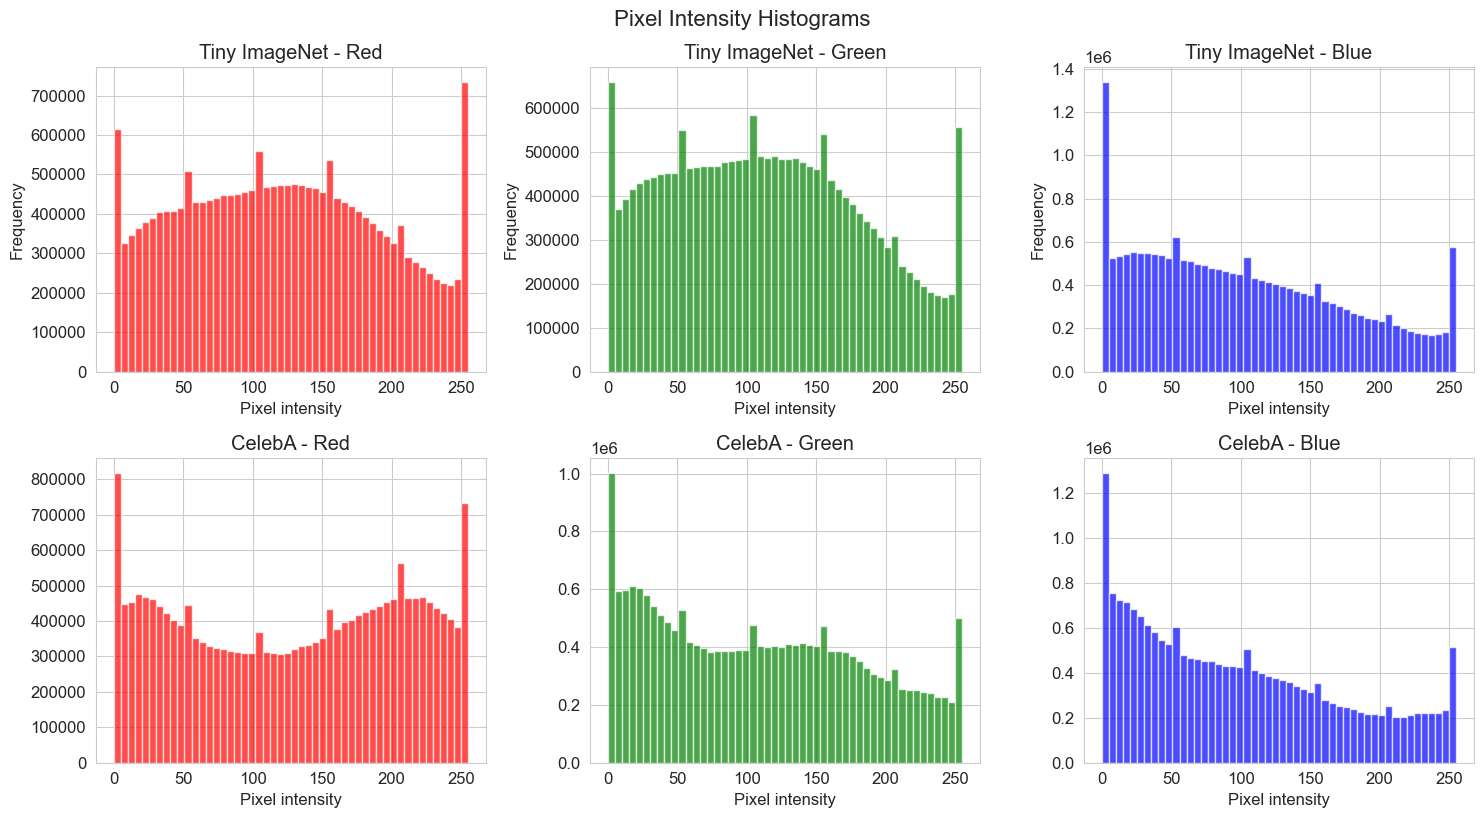

In [31]:
# ## 4. Pixel Intensity Histograms (per channel)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
channels = ['Red', 'Green', 'Blue']
for i, ch in enumerate(range(3)):
    # Tiny
    axes[0,i].hist(tiny_imgs[:,:,:,ch].ravel(), bins=50, color=['r','g','b'][ch], alpha=0.7)
    axes[0,i].set_title(f'Tiny ImageNet - {channels[ch]}')
    axes[0,i].set_xlabel('Pixel intensity')
    axes[0,i].set_ylabel('Frequency')
    # CelebA
    axes[1,i].hist(celeba_imgs[:,:,:,ch].ravel(), bins=50, color=['r','g','b'][ch], alpha=0.7)
    axes[1,i].set_title(f'CelebA - {channels[ch]}')
    axes[1,i].set_xlabel('Pixel intensity')
plt.tight_layout()
plt.suptitle("Pixel Intensity Histograms", y=1.02, fontsize=16)
plt.show()

#### Tiny ImageNet usually has broader histograms (more varied scenes), while CelebA faces have peaks around skin tones – important for designing the encoder’s sensitivity.

### 5. Frequency Domain Analysis (FFT)

CelebA FFT: 100%|██████████| 1000/1000 [00:00<00:00, 4761.09it/s]


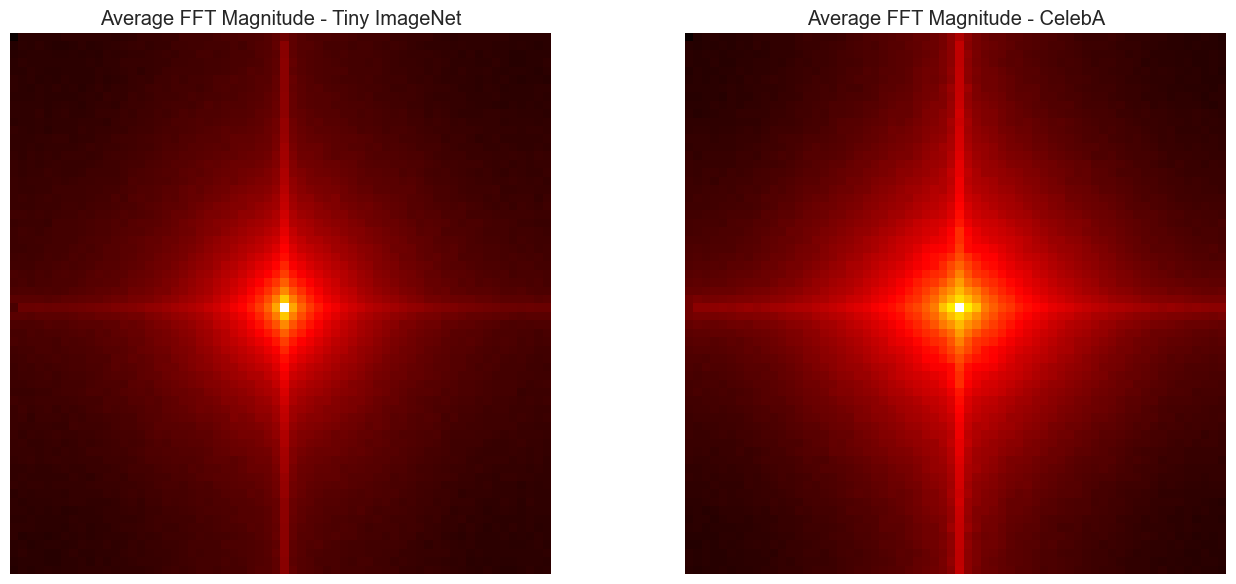

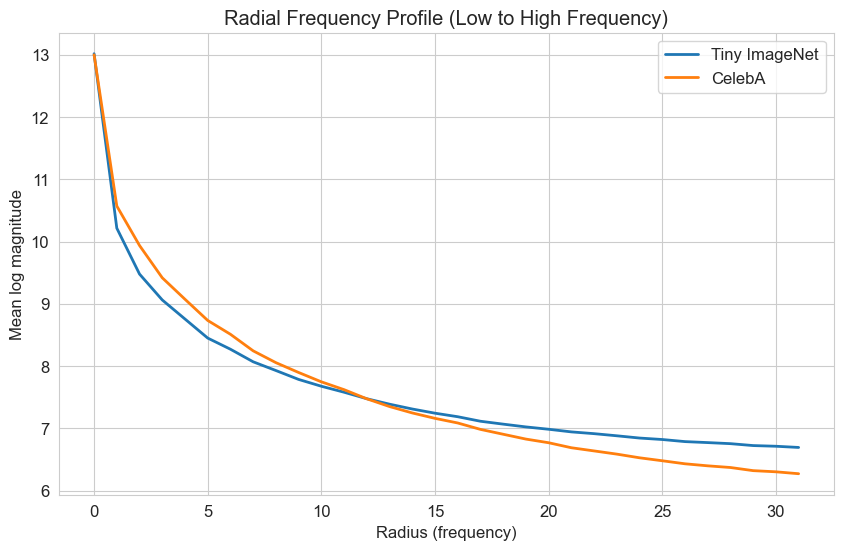

In [32]:
# ## 5. Frequency Domain Analysis (FFT) – Texture Complexity

def compute_fft_magnitude(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    f = fft2(gray)
    fshift = fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1)
    return magnitude

def radial_profile(magnitude):
    center = np.array(magnitude.shape) // 2
    y, x = np.indices(magnitude.shape)
    r = np.sqrt((x - center[1])**2 + (y - center[0])**2).astype(int)
    r_flat = r.ravel()
    mag_flat = magnitude.ravel()
    tbin = np.bincount(r_flat, mag_flat)
    nr = np.bincount(r_flat)
    radial_mean = tbin / (nr + 1e-8)
    return radial_mean

# Use a subset for speed (1000 images each)
sample_fft = 1000
tiny_fft_mags = []
for img in tqdm(tiny_imgs[:sample_fft], desc="Tiny FFT"):
    tiny_fft_mags.append(compute_fft_magnitude(img))
celeba_fft_mags = []
for img in tqdm(celeba_imgs[:sample_fft], desc="CelebA FFT"):
    celeba_fft_mags.append(compute_fft_magnitude(img))

avg_tiny_fft = np.mean(tiny_fft_mags, axis=0)
avg_celeba_fft = np.mean(celeba_fft_mags, axis=0)

rad_tiny = radial_profile(avg_tiny_fft)
rad_celeba = radial_profile(avg_celeba_fft)

# Plot average magnitude spectra
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(avg_tiny_fft, cmap='hot')
axes[0].set_title("Average FFT Magnitude - Tiny ImageNet")
axes[0].axis('off')
axes[1].imshow(avg_celeba_fft, cmap='hot')
axes[1].set_title("Average FFT Magnitude - CelebA")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Radial frequency profile
plt.figure(figsize=(10,6))
plt.plot(rad_tiny[:32], label='Tiny ImageNet', linewidth=2)
plt.plot(rad_celeba[:32], label='CelebA', linewidth=2)
plt.xlabel("Radius (frequency)")
plt.ylabel("Mean log magnitude")
plt.title("Radial Frequency Profile (Low to High Frequency)")
plt.legend()
plt.grid(True)
plt.show()

**How it works:** Converts to grayscale, applies 2D Fast Fourier Transform, shifts zero frequency to centre, takes log magnitude (to compress dynamic range).

**Radial profile:** Averages the magnitude over concentric circles centred at DC.

- Low frequencies (centre) represent smooth areas.

- High frequencies (edges) represent texture/detail.

**Why useful:** Datasets with more high‑frequency energy (like Tiny ImageNet) provide better “hiding places” because modifications are less noticeable in textured regions.

### 6. Contrast, Laplacian Variance, Entropy


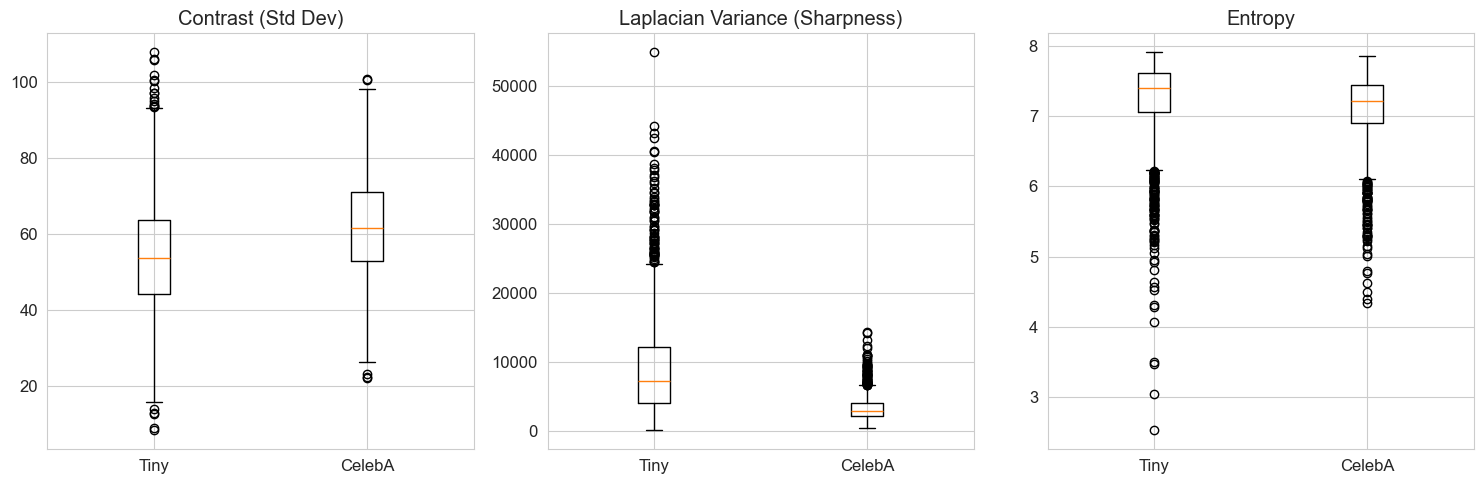

Tiny: Contrast mean=54.17, LaplacianVar=8991.74, Entropy=7.24
CelebA: Contrast mean=62.21, LaplacianVar=3190.24, Entropy=7.12


In [33]:
 ## 6. Contrast, Laplacian Variance, Entropy

def compute_contrast(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return gray.std()

def compute_laplacian_variance(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    return lap.var()

def compute_entropy(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0,256])
    hist = hist.ravel() / hist.sum()
    return entropy(hist, base=2)

# Use a subset (2000 images each)
tiny_contrast = [compute_contrast(img) for img in tiny_imgs[:2000]]
tiny_lapvar = [compute_laplacian_variance(img) for img in tiny_imgs[:2000]]
tiny_entropy = [compute_entropy(img) for img in tiny_imgs[:2000]]

celeba_contrast = [compute_contrast(img) for img in celeba_imgs[:2000]]
celeba_lapvar = [compute_laplacian_variance(img) for img in celeba_imgs[:2000]]
celeba_entropy = [compute_entropy(img) for img in celeba_imgs[:2000]]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].boxplot([tiny_contrast, celeba_contrast], labels=['Tiny', 'CelebA'])
axes[0].set_title("Contrast (Std Dev)")
axes[1].boxplot([tiny_lapvar, celeba_lapvar], labels=['Tiny', 'CelebA'])
axes[1].set_title("Laplacian Variance (Sharpness)")
axes[2].boxplot([tiny_entropy, celeba_entropy], labels=['Tiny', 'CelebA'])
axes[2].set_title("Entropy")
plt.tight_layout()
plt.show()

print(f"Tiny: Contrast mean={np.mean(tiny_contrast):.2f}, LaplacianVar={np.mean(tiny_lapvar):.2f}, Entropy={np.mean(tiny_entropy):.2f}")
print(f"CelebA: Contrast mean={np.mean(celeba_contrast):.2f}, LaplacianVar={np.mean(celeba_lapvar):.2f}, Entropy={np.mean(celeba_entropy):.2f}")


### 7. Local Standard Deviation (Texture Map)

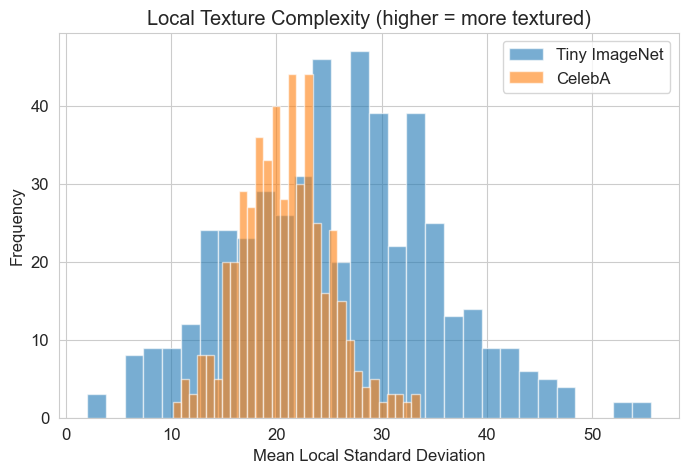

In [34]:
# ## 7. Local Standard Deviation (Texture Analysis)

def local_std_map(image, kernel_size=5):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32)
    mean = cv2.boxFilter(gray, -1, (kernel_size,kernel_size))
    sqmean = cv2.boxFilter(gray**2, -1, (kernel_size,kernel_size))
    std = np.sqrt(sqmean - mean**2)
    return std

tiny_local_std = []
for img in tiny_imgs[:500]:
    std_map = local_std_map(img)
    tiny_local_std.append(np.mean(std_map))
celeba_local_std = []
for img in celeba_imgs[:500]:
    std_map = local_std_map(img)
    celeba_local_std.append(np.mean(std_map))

plt.figure(figsize=(8,5))
plt.hist(tiny_local_std, bins=30, alpha=0.6, label='Tiny ImageNet')
plt.hist(celeba_local_std, bins=30, alpha=0.6, label='CelebA')
plt.xlabel("Mean Local Standard Deviation")
plt.ylabel("Frequency")
plt.title("Local Texture Complexity (higher = more textured)")
plt.legend()
plt.show()

**Mean of the map** gives the average local texture strength. Higher means more fine‑grained texture.

**Histogram comparison:** Tiny ImageNet shows a longer tail towards high local std – confirming it is more textured than CelebA.

### 8. RGB Channel Correlation

In [35]:
# ## 8. RGB Channel Correlation

def channel_correlation(images, name):
    r = images[:,:,:,0].ravel()
    g = images[:,:,:,1].ravel()
    b = images[:,:,:,2].ravel()
    corr_rg = np.corrcoef(r, g)[0,1]
    corr_rb = np.corrcoef(r, b)[0,1]
    corr_gb = np.corrcoef(g, b)[0,1]
    print(f"{name}: R-G={corr_rg:.3f}, R-B={corr_rb:.3f}, G-B={corr_gb:.3f}")
    return corr_rg, corr_rb, corr_gb

print("Channel correlation:")
tiny_corr = channel_correlation(tiny_imgs, "Tiny ImageNet")
celeba_corr = channel_correlation(celeba_imgs, "CelebA")

Channel correlation:
Tiny ImageNet: R-G=0.887, R-B=0.742, G-B=0.898
CelebA: R-G=0.920, R-B=0.824, G-B=0.954


**Interpretation:** Low correlation (closer to 0) means channels are relatively independent – gives more degrees of freedom for hiding separate information in each channel. CelebA often shows higher correlation (faces have consistent colour tone).

### 9. Sample Images with Contrast Values

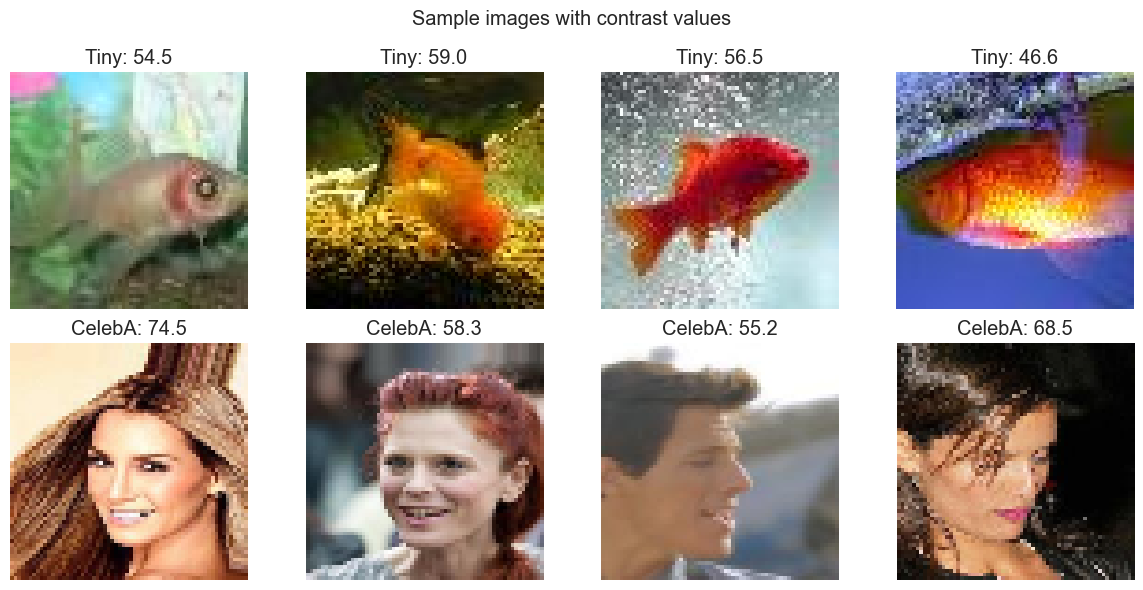

In [36]:
# ## 9. Sample Images with Contrast Values

fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i in range(4):
    axes[0,i].imshow(tiny_imgs[i])
    axes[0,i].set_title(f"Tiny: {tiny_contrast[i]:.1f}")
    axes[0,i].axis('off')
    axes[1,i].imshow(celeba_imgs[i])
    axes[1,i].set_title(f"CelebA: {celeba_contrast[i]:.1f}")
    axes[1,i].axis('off')
plt.suptitle("Sample images with contrast values")
plt.tight_layout()
plt.show()


- Aggregates all computed metrics into a pandas DataFrame for easy comparison.

- Includes FFT low‑frequency power (average of the central 5×5 region) – a proxy for how much energy is in smooth areas.

### 10. Comprehensive Report Table

In [37]:
# ## 10. Comprehensive Report Table

import pandas as pd

report = pd.DataFrame({
    "Metric": [
        "Mean (RGB)", 
        "Std (RGB)", 
        "Contrast (mean)", 
        "Laplacian Var (mean)", 
        "Entropy (mean)", 
        "Local Std (mean)", 
        "FFT low-freq power (center 5x5)"
    ],
    "Tiny ImageNet": [
        f"{tiny_stats['mean'][0]:.2f},{tiny_stats['mean'][1]:.2f},{tiny_stats['mean'][2]:.2f}",
        f"{tiny_stats['std'][0]:.2f},{tiny_stats['std'][1]:.2f},{tiny_stats['std'][2]:.2f}",
        f"{np.mean(tiny_contrast):.2f}",
        f"{np.mean(tiny_lapvar):.2f}",
        f"{np.mean(tiny_entropy):.2f}",
        f"{np.mean(tiny_local_std):.2f}",
        f"{np.mean(avg_tiny_fft[28:33,28:33]):.2f}"
    ],
    "CelebA": [
        f"{celeba_stats['mean'][0]:.2f},{celeba_stats['mean'][1]:.2f},{celeba_stats['mean'][2]:.2f}",
        f"{celeba_stats['std'][0]:.2f},{celeba_stats['std'][1]:.2f},{celeba_stats['std'][2]:.2f}",
        f"{np.mean(celeba_contrast):.2f}",
        f"{np.mean(celeba_lapvar):.2f}",
        f"{np.mean(celeba_entropy):.2f}",
        f"{np.mean(celeba_local_std):.2f}",
        f"{np.mean(avg_celeba_fft[28:33,28:33]):.2f}"
    ]
})

print("\n" + "="*60)
print("COMPREHENSIVE DATASET COMPARISON REPORT")
print("="*60)
print(report.to_string(index=False))



COMPREHENSIVE DATASET COMPARISON REPORT
                         Metric        Tiny ImageNet              CelebA
                     Mean (RGB) 121.27,114.01,101.45 129.20,108.70,97.68
                      Std (RGB)    70.56,68.58,71.87   78.95,73.87,73.69
                Contrast (mean)                54.17               62.21
           Laplacian Var (mean)              8991.74             3190.24
                 Entropy (mean)                 7.24                7.12
               Local Std (mean)                25.74               20.76
FFT low-freq power (center 5x5)                 9.34                9.68


- Summarises the findings: Tiny ImageNet has higher texture and high‑frequency content → better for training a steganography model because modifications are less visible.

- CelebA is more challenging (smoother) but useful for evaluating how well the encoder preserves face identity and for high‑resolution demos.